In [12]:
using JuMP, SCS, LinearAlgebra, Random
using Graphs, GraphPlot, Colors
using Cairo, Fontconfig

## **Formulación de Max-Cut**

Dado un grafo $G = (V, E)$ con pesos $w_{ij}$ para las aristas $(i,j) \in E$, el problema **Max-Cut** consiste en encontrar un subconjunto $S \subseteq V$ que maximice el corte, es decir, la suma de los pesos de las aristas que tienen un extremo en $S$ y otro en $V \setminus S$.

Se puede formular como:

$$
\max_{S \subseteq V} \sum_{\substack{i \in S \\ j \notin S}} w_{ij}
$$

---

# Costos asociados a subconjuntos $S$

A cada subconjunto $S \subseteq V$ le asociamos un costo evaluando la función objetivo sobre ese conjunto.

Usamos variables binarias $x_i \in \{-1, 1\}$ que indican a qué lado del corte está el nodo $i$:

$$
x_i = \begin{cases}
1 & \text{si } i \in S \\
-1 & \text{si } i \notin S
\end{cases}
$$

El costo del corte se puede escribir como:

$$
\frac{1}{2} \sum_{\substack{i<j>}} w_{ij} (1 - x_i x_j)
$$

donde el factor $\frac{1}{2}$ evita contar dos veces cada arista y adapta el signo.

---

# Relajación con vectores unitarios

La idea de la relajación es reemplazar cada variable binaria $x_i$ por un vector unitario $v_i \in \mathbb{R}^n$ tal que:

$$
\| v_i \| = 1
$$

Entonces la función objetivo se reescribe como:

$$
\max_{\substack{v_i \in \mathbb{R}^n \\ \|v_i\| = 1}} \frac{1}{2} \sum_{i<j} w_{ij} (1 - v_i^\top v_j)
$$

Aquí, el producto escalar $v_i^\top v_j$ reemplaza al producto $x_i x_j$ de las variables binarias.

---

# Relajación semidefinida positiva (SDP)

Definimos la matriz $Y \in \mathbb{R}^{n \times n}$ con entradas:

$$
Y_{ij} = v_i^\top v_j
$$

La matriz $Y$ es simétrica, semidefinida positiva y tiene diagonal igual a 1 (porque $\|v_i\|^2 = 1$):

$$
Y \succeq 0, \quad Y_{ii} = 1 \quad \forall i
$$

El problema de relajación queda como:

$$
\max_{Y \succeq 0} \frac{1}{4} \sum_{i,j} w_{ij} (1 - Y_{ij}) \quad \text{sujeto a} \quad Y_{ii} = 1 \ \forall i
$$

---

# Obtención de los vectores $v_i$ a partir de $Y$

Si $Y$ cumple las condiciones anteriores, podemos factorizarla como:

$$
Y = B^\top B
$$

donde $B \in \mathbb{R}^{k \times n}$ (para algún $k \leq n$) y cada columna $b_i$ es un vector unitario que corresponde a $v_i$.

Esta factorización es la **descomposición semidefinida positiva** de $Y$, y nos permite obtener los vectores que aproximan la solución original del problema Max-Cut.

---

# Valor esperado del corte:

Una vez que tengo los vectores $v_i$, tomo un vector $r$ de dirección aleatoria (por ejemplo, uniformemente distribuido sobre la esfera unitaria) y me quedo con los índices $i$ tales que el producto interno $v_i \cdot r$ sea mayor o igual a 0.

Es decir, defino el conjunto:

$$
S = \left\{ i \in V \mid v_i^\top r \geq 0 \right\}
$$

Sea $W$ el costo asociado al conjunto de nodos $S$ obtenido a partir de este corte aleatorio.

Queremos demostrar que el valor esperado de $W$, denotado $\mathbb{E}[W]$, satisface:

$$
\mathbb{E}[W] \geq \alpha \cdot \text{OPT}
$$

donde $\text{OPT}$ es el valor óptimo del problema de Max-Cut relajado, y $\alpha$ es una constante ($\alpha \approx 0.87856$).

---

Veamos, antes de entrar en las demostraciones:
- Un ejemplo simple de cómo funciona el método.
- Un ejemplo más grande de cómo funciona el método y el mismo ejemplo pero resuelto con enumeración de casos (sirve porque son pocos nados).

Asignación de nodos (1 o -1): [-1, 1, 1, -1]
Valor del corte: 25.04


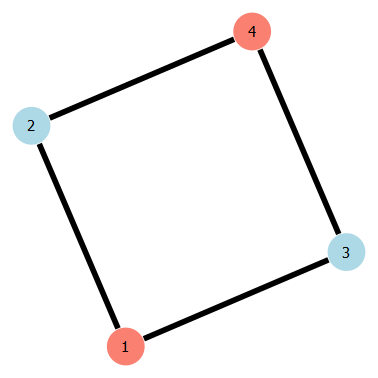

In [13]:
# Ejemplo simple de prueba.
# -----------------------------
# ⚙️ Parámetros del grafo
# -----------------------------
n = 4                         # número de nodos
p = 0.54                     # probabilidad de arista
max_weight = 10.0           # pesos aleatorios hasta este valor
Random.seed!(1234)

# -----------------------------
# 📈 Generar grafo aleatorio
# -----------------------------
g = erdos_renyi(n, p)  # Crea un grafo aleatorio con n nodos y probabilidad p de arista
edges = [(u,v) for u in 1:n for v in u+1:n if has_edge(g,u,v)]  # Lista de aristas presentes en el grafo
weights = Dict((u,v)=>rand()*max_weight for (u,v) in edges)  # Asigna un peso aleatorio a cada arista

# -----------------------------
# 🧮 Resolver la relajación SDP
# -----------------------------
model = Model(SCS.Optimizer)  # Crea un modelo de optimización usando el solver SCS
set_silent(model)  # Silencia la salida del solver

@variable(model, X[1:n, 1:n], PSD)  # Declara la variable de decisión: matriz simétrica positiva semidefinida (PSD)
@constraint(model, [i=1:n], X[i,i] == 1)  # Restringe la diagonal de X a 1 (norma de los vectores)
@objective(model, Max, sum(weights[(i,j)] * (1 - X[i,j]) / 2 for (i,j) in edges))  # Define la función objetivo (relajación SDP de Max-Cut)

optimize!(model)  # Resuelve el modelo
X_opt = value.(X)  # Obtiene la matriz solución óptima

# -----------------------------
# 🔄 Redondeo aleatorio
# -----------------------------
eigvals, eigvecs = eigen(X_opt)  # Descompone X_opt en valores y vectores propios
eigvals_clipped = clamp.(eigvals, 0, Inf)  # Asegura que los valores propios sean no negativos
V = eigvecs * diagm(sqrt.(eigvals_clipped))  # Calcula la matriz de vectores para el redondeo

r = randn(n)  # Genera un vector aleatorio para definir el corte
cut = [dot(V[i,:], r) >= 0 ? 1 : -1 for i in 1:n]  # Asigna cada nodo a un lado del corte según el signo del producto escalar
cut_value = sum(weights[(i,j)] for (i,j) in edges if cut[i] != cut[j])  # Suma los pesos de las aristas que cruzan el corte

println("Asignación de nodos (1 o -1): ", cut)  # Muestra la asignación de nodos
println("Valor del corte: ", round(cut_value, digits=2))  # Muestra el valor del corte

# -----------------------------
# 🎨 Visualización
# -----------------------------
node_colors = [cut[i] == 1 ? colorant"lightblue" : colorant"salmon" for i in 1:n]  # Color de cada nodo según el lado del corte
edge_colors = [cut[u] != cut[v] ? colorant"black" : RGBA(0,0,0,0.1) for (u,v) in edges]  # Color de cada arista según si cruza el corte
edge_widths = [cut[u] != cut[v] ? 2.5 : 0.5 for (u,v) in edges]  # Grosor de cada arista según si cruza el corte

# Graficar
gplot(g;
    nodelabel=1:n,  # Etiquetas de los nodos
    nodefillc=node_colors,  # Colores de los nodos
    edgestrokec=edge_colors,  # Colores de las aristas
    edgelinewidth=edge_widths,  # Grosor de las aristas
    layout=spring_layout  # Tipo de layout para la visualización
)


Asignación de nodos (1 o -1): [-1, -1, 1, -1, -1, -1, -1, 1, 1, 1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1]
Valor del corte: 332.16


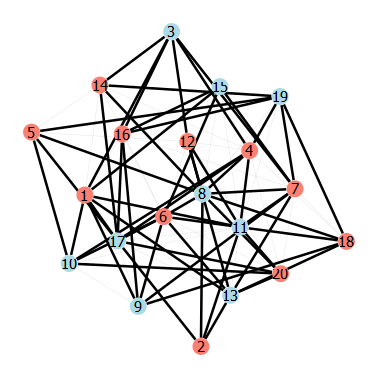

In [14]:
# Ejemplo más grande. Resuelto con relajación SDP y redondeo aleatorio. En un siguiente paso, resolvemos a fuerza bruta
# -----------------------------
# ⚙️ Parámetros del grafo
# -----------------------------
n = 20                     # número de nodos
p = 0.4                     # probabilidad de arista
max_weight = 10.0           # pesos aleatorios hasta este valor
Random.seed!(53)

# -----------------------------
# 📈 Generar grafo aleatorio
# -----------------------------
g = erdos_renyi(n, p)
edges = [(u,v) for u in 1:n for v in u+1:n if has_edge(g,u,v)]
weights = Dict((u,v)=>rand()*max_weight for (u,v) in edges)

# -----------------------------
# 🧮 Resolver la relajación SDP
# -----------------------------
model = Model(SCS.Optimizer)
set_silent(model)

@variable(model, X[1:n, 1:n], PSD)
@constraint(model, [i=1:n], X[i,i] == 1)
@objective(model, Max, sum(weights[(i,j)] * (1 - X[i,j]) / 2 for (i,j) in edges))

optimize!(model)
X_opt = value.(X)

# -----------------------------
# 🔄 Redondeo aleatorio
# -----------------------------
eigvals, eigvecs = eigen(X_opt)
eigvals_clipped = clamp.(eigvals, 0, Inf)
V = eigvecs * diagm(sqrt.(eigvals_clipped))

r = randn(n)
cut = [dot(V[i,:], r) >= 0 ? 1 : -1 for i in 1:n]
cut_value = sum(weights[(i,j)] for (i,j) in edges if cut[i] != cut[j])

println("Asignación de nodos (1 o -1): ", cut)
println("Valor del corte: ", round(cut_value, digits=2))

# -----------------------------
# 🎨 Visualización
# -----------------------------
node_colors = [cut[i] == 1 ? colorant"lightblue" : colorant"salmon" for i in 1:n]
edge_colors = [cut[u] != cut[v] ? colorant"black" : RGBA(0,0,0,0.1) for (u,v) in edges]
edge_widths = [cut[u] != cut[v] ? 2.5 : 0.5 for (u,v) in edges]

# Graficar
gplot(g;
    nodelabel=1:n,
    nodefillc=node_colors,
    edgestrokec=edge_colors,
    edgelinewidth=edge_widths,
    layout=spring_layout
)


Corte óptimo: [-1, -1, 1, -1, -1, -1, -1, 1, 1, 1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1]
Valor óptimo: 332.16443359131847


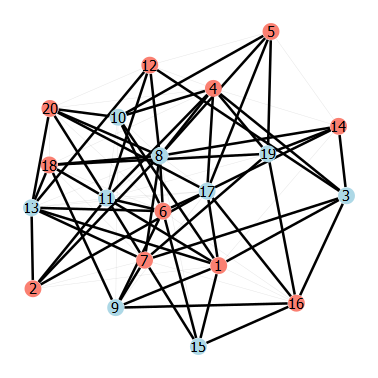

In [15]:
# Supone que tenés definidos: n, edges, weights. Sirve hasta n = 20 aproximadamente.

function maxcut_bruteforce(n, edges, weights)
    best_cut = nothing                # Guarda la mejor asignación encontrada
    best_value = -Inf                 # Guarda el mejor valor de corte encontrado

    # Recorre todas las particiones posibles (excepto la trivial: todo 1 o todo -1)
    for mask in 1:(2^(n-1)-1)         # Cada máscara representa una partición de los nodos
        cut = [((mask >> (i-1)) & 1) == 1 ? 1 : -1 for i in 1:n]  # Asigna 1 o -1 a cada nodo según la máscara
        cut_value = sum(weights[(i,j)] for (i,j) in edges if cut[i] != cut[j])  # Suma los pesos de las aristas que cruzan el corte
        if cut_value > best_value     # Si el valor de este corte es mejor que el mejor hasta ahora
            best_value = cut_value    # Actualiza el mejor valor
            best_cut = copy(cut)      # Actualiza la mejor asignación
        end
    end
    return best_cut, best_value       # Devuelve la mejor asignación y su valor
end

# Ejemplo de uso:
opt_cut, opt_value = maxcut_bruteforce(n, edges, weights)  # Llama a la función con el grafo actual
println("Corte óptimo: ", opt_cut)                         # Muestra la asignación óptima de nodos
println("Valor óptimo: ", opt_value)                       # Muestra

# -----------------------------
# 🎨 Visualización
# -----------------------------
node_colors = [cut[i] == 1 ? colorant"lightblue" : colorant"salmon" for i in 1:n]
edge_colors = [cut[u] != cut[v] ? colorant"black" : RGBA(0,0,0,0.1) for (u,v) in edges]
edge_widths = [cut[u] != cut[v] ? 2.5 : 0.5 for (u,v) in edges]

# Graficar
gplot(g;
    nodelabel=1:n,
    nodefillc=node_colors,
    edgestrokec=edge_colors,
    edgelinewidth=edge_widths,
    layout=spring_layout
)

---

## Análisis probabilístico del corte aleatorio ##

Necesitamos los siguientes lemas para analizar el valor esperado del corte aleatorio:

---


## **Lema 1:**

Sea $r$ un vector aleatorio uniformemente distribuido en la esfera unitaria, y sea $\operatorname{sg}(x)$ la función signo:

$$
\operatorname{sg}(x) =
\begin{cases}
1 & \text{si } x \geq 0 \\
-1 & \text{si } x < 0
\end{cases}
$$

Entonces, para dos vectores unitarios $v_i$ y $v_j$:

$$
\mathbb{P} \left( \operatorname{sg}(v_i^\top r) \ne \operatorname{sg}(v_j^\top r) \right) = \frac{1}{\pi} \arccos(v_i^\top v_j)
$$

# Demostración:

Sea $r \in \mathbb{R}^n$ un vector aleatorio uniformemente distribuido en la esfera unidad $S^{n-1} = \{ x \in \mathbb{R}^n : \|x\| = 1 \}$.

Sean $v_i, v_j \in S^{n-1}$ dos vectores unitarios fijos. Queremos probar que:

$$
\mathbb{P}(\operatorname{sgn}(v_i \cdot r) \ne \operatorname{sgn}(v_j \cdot r)) = \frac{1}{\pi} \arccos(v_i \cdot v_j)
$$

---

# Paso 1: Descomposición de la probabilidad

La probabilidad de que los signos difieran es la suma de los eventos en que uno es positivo y el otro no:

$$
\mathbb{P}(\operatorname{sgn}(v_i \cdot r) \ne \operatorname{sgn}(v_j \cdot r)) =
\mathbb{P}(v_i \cdot r > 0,\ v_j \cdot r \leq 0) +
\mathbb{P}(v_i \cdot r \leq 0,\ v_j \cdot r > 0)
$$

Por simetría de la distribución uniforme sobre la esfera, ambas probabilidades son iguales:

$$
= 2 \cdot \mathbb{P}(v_i \cdot r > 0,\ v_j \cdot r \leq 0)
$$

---

# Paso 2: Casos extremos

- Si $v_i = v_j$, entonces $\operatorname{sgn}(v_i \cdot r) = \operatorname{sgn}(v_j \cdot r)$ para todo $r$, por lo tanto la probabilidad es $0$.
- Si $v_i = -v_j$, entonces los signos siempre son opuestos (salvo en el conjunto de medida cero donde ambos productos son cero), así que la probabilidad es $1$.

Ambos casos extremos son coherentes con la fórmula:

- $\arccos(1) = 0 \Rightarrow \frac{1}{\pi} \cdot 0 = 0$
- $\arccos(-1) = \pi \Rightarrow \frac{1}{\pi} \cdot \pi = 1$

---

# Paso 3: Interpretación geométrica para el caso general

Sea $\theta = \arccos(v_i \cdot v_j)$ el ángulo entre los vectores $v_i$ y $v_j$.

Consideramos los hiperplanos:

- $\Pi_1: \{ r \in \mathbb{R}^n : v_i \cdot r = 0 \}$
- $\Pi_2: \{ r \in \mathbb{R}^n : v_j \cdot r = 0 \}$

Cada hiperplano divide la esfera $S^{n-1}$ en dos hemisferios. Por ejemplo, $\Pi_1$ separa los puntos $r$ donde $v_i \cdot r > 0$ de aquellos donde $v_i \cdot r < 0$.

Las normales a estos hiperplanos son precisamente $v_i$ y $v_j$. Entonces, el ángulo entre los hiperplanos $\Pi_1$ y $\Pi_2$ se define como el ángulo entre sus normales, es decir, $\theta$.

La región que nos interesa es la intersección:

$$
A = \{ r \in S^{n-1} : v_i \cdot r > 0,\ v_j \cdot r \leq 0 \}
$$

Esta región es un "sector esférico" cuya proporción respecto al área total de la esfera es proporcional al ángulo $\theta$ que separa a $v_i$ de $v_j$.

Más precisamente, la medida (probabilidad) de este sector es:

$$
\mathbb{P}(v_i \cdot r > 0,\ v_j \cdot r \leq 0) = \frac{\theta}{2\pi}
$$

---

# Paso 4: Conclusión

Entonces:

$$
\mathbb{P}(\operatorname{sgn}(v_i \cdot r) \ne \operatorname{sgn}(v_j \cdot r)) =
2 \cdot \frac{\theta}{2\pi} = \frac{\theta}{\pi} = \frac{1}{\pi} \arccos(v_i \cdot v_j)
$$

Fin de la demostración

---

## **Lema 2:**

Si $-1 \leq y \leq 1$, entonces se cumple que:

$$
\frac{1}{\pi} \arccos(y) \geq \alpha \cdot \frac{1}{2}(1 - y)
$$

donde $\alpha = 0.87856\ldots$ es una constante conocida del análisis del algoritmo de Goemans-Williamson.

---


Queremos demostrar que:

$$
\frac{1}{\pi} \arccos(y) \geq \alpha \cdot \frac{1}{2} (1 - y) \quad \text{para todo } y \in [-1, 1]
$$

donde $\alpha$ es una constante positiva tal que $\alpha > 0.87856$.

---

# Paso 1: Cambio de variable

Sabemos que $y \in [-1,1]$ si y sólo si $\theta := \arccos(y) \in [0,\pi]$, ya que $\arccos$ es decreciente en ese intervalo.

Entonces, definimos $\theta := \arccos(y)$ y reescribimos la desigualdad:

$$
\frac{1}{\pi} \theta \geq \alpha \cdot \frac{1}{2} \left(1 - \cos(\theta)\right) \quad \text{para todo } \theta \in [0, \pi]
$$

Multiplicando ambos lados por $2$:

$$
\frac{2}{\pi} \cdot \frac{\theta}{1 - \cos(\theta)} \geq \alpha
$$

Por lo tanto, el lema se verifica si definimos:

$$
\alpha := \min_{\theta \in [0,\pi]} \left( \frac{2}{\pi} \cdot \frac{\theta}{1 - \cos(\theta)} \right)
$$

Y encontramos que dicho mínimo es **mayor a 0.87856**, lo que demostraría el lema.

---

# Paso 2: Análisis de la función

Sea $f(\theta)$ la función definida como:

$$
f(\theta) := \frac{2}{\pi} \theta - 0.87856 (1 - \cos(\theta))
$$

Queremos demostrar que $f(\theta) > 0$ para todo $\theta \in [0,\pi]$. Es decir, que:

$$
\frac{2}{\pi} \theta > 0.87856 (1 - \cos(\theta)) \quad \forall \theta \in [0,\pi]
$$

---

# Paso 3: Propiedades analíticas de $f$

- La función $f$ es $C^\infty$ en $[0,\pi]$ (es infinitamente derivable), ya que es combinación de funciones suaves.
- $f(0) = \frac{2}{\pi} \cdot 0 - 0.87856 (1 - \cos(0)) = 0$
- $f(\pi) = \frac{2}{\pi} \cdot \pi - 0.87856 (1 - \cos(\pi)) = 2 - 0.87856 \cdot (1 - (-1)) = 2 - 0.87856 \cdot 2 = 2 - 1.75712 \approx 0.24288 > 0$
- $f$ es continua en $[0,\pi]$, por lo tanto alcanza sus puntos críticos en ese intervalo cerrado y acotado.

---

# Paso 4: Derivada y puntos críticos

Derivamos $f$ respecto de $\theta$:

$$
f'(\theta) = \frac{2}{\pi} - 0.87856 \cdot \sin(\theta)
$$

Queremos estudiar los puntos críticos, es decir, los $\theta$ tales que $f'(\theta) = 0$:

$$
f'(\theta) = 0 \quad \Leftrightarrow \quad \sin(\theta) = \frac{2}{\pi \cdot 0.87856} 
$$


Queremos encontrar los puntos críticos, es decir, los valores de $\theta \in [0, \pi]$ tales que $f'(\theta) = 0$:

$$
f'(\theta) = 0 \quad \Leftrightarrow \quad \sin(\theta) = \frac{2}{\pi \cdot 0.87856}
$$

Calculamos:

$$
\frac{2}{\pi \cdot 0.87856} \approx \frac{2}{2.75966} \approx 0.7247
$$

Entonces:

$$
\theta = \arcsin(0.7247) \approx 0.81 \text{ radianes}
$$

Cómo la función $\sin(\theta)$ es periódica, el otro valor con la misma imagen de seno en $[0, \pi]$ es:

$$
\theta = \pi - 0.81 \approx 2.33 \text{ radianes}
$$

Por lo tanto, los únicos **puntos críticos en el intervalo $[0, \pi]$** son:

$$
\theta_1 \approx 0.81, \quad \theta_2 \approx 2.33
$$

Veamos ahora que $f(\theta_1) > 0$ y $f(\theta_2) > 0$:

Usamos Julia para evaluarlo numéricamente:

In [16]:
# Para alta precisión
setprecision(BigFloat, 50)

# Constantes con alta precisión
coef1 = BigFloat(2) / big(pi)
coef2 = BigFloat("0.87856")

# Función f(theta)
function f(theta::BigFloat)
    return coef1 * theta - coef2 * (1 - cos(theta))
end

# Cálculo de puntos críticos
theta_critico_1 = asin(coef1 / coef2) #arcsen de thetta
theta_critico_2 = big(pi) - theta_critico_1 #Al sumar pi, se obtiene otro valor tal que la imagen da 0

println("Theta crítico 1: ", theta_critico_1)
println("f(theta crítico 1): ", f(theta_critico_1))

println("Theta crítico 2: ", theta_critico_2)
println("f(theta crítico 2): ", f(theta_critico_2))

println("\nEvaluando f en valores cercanos a theta crítico 2:")  #Cómo el valor me da muy cercano a 0, quiero chequear que efectivamente nunca es menor a 0. Lo hago de forma numérica.

deltas = [-1e-10, -1e-9, -1e-8, 0.0, 1e-8, 1e-9, 1e-10]

for delta in deltas
    val = theta_critico_2 + BigFloat(delta)
    println("theta = $(val), f(theta) = $(f(val))")
end


Theta crítico 1: 0.81047890696854274
f(theta crítico 1): 0.24286782831528253
Theta crítico 2: 2.3311137466212486
f(theta crítico 2): 1.21716847161224e-05

Evaluando f en valores cercanos a theta crítico 2:
theta = 2.3311137465212504, f(theta) = 1.21716847161224e-05
theta = 2.3311137456212485, f(theta) = 1.21716847161224e-05
theta = 2.3311137366212478, f(theta) = 1.2171684714346043e-05
theta = 2.3311137466212486, f(theta) = 1.21716847161224e-05
theta = 2.3311137566212494, f(theta) = 1.2171684714346043e-05
theta = 2.3311137476212487, f(theta) = 1.21716847161224e-05
theta = 2.3311137467212468, f(theta) = 1.21716847161224e-05



Como $f(\theta)$ > 0 para todo $\theta \in [0,\pi]$, entonces:

$$
\frac{1}{\pi} \arccos(y) > \alpha \cdot \frac{1}{2}(1 - y) \quad \text{para todo } y \in [-1,1]
$$

Por lo tanto, $\alpha > 0.87856$.

Fin de la demostración.

Veamos, entonces, que 
$$
\mathbb{E}[W] \geq \alpha \cdot \text{OPT} 
$$
Demostración:
$$
\mathbb{E}[W] = \sum_{i<j} w_{ij} \mathbb{P} \left( \operatorname{sg}(v_i^\top r) \ne \operatorname{sg}(v_j^\top r) \right) 
$$
Por lema 1,
$$
\mathbb{E}[W] = \sum_{i<j} w_{ij} \frac{1}{\pi} \arccos(v_i \cdot v_j)
$$
Por lema 2,
$$
\mathbb{E}[W] \geq \sum_{i<j} w_{ij} \alpha \frac{1}{2} (1 - v_i v_j)
$$
Cómo usar los vectores unitarios era una relajación del problema binario original, el óptimo de la relajación es mayor al óptimo del problema original. Por lo que podemos concluir que:
$$
\mathbb{E}[W] \geq \sum_{i<j} w_{ij} \alpha \frac{1}{2} (1 - x_i x_j)
$$


Asignación de nodos (1 o -1): [1, 1, 1, 1, 1, -1, -1, 1, 1, 1, 1, -1, 1, 1, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, 1, 1, 1, -1, 1, 1, -1, -1, -1, -1, -1, -1, 1, -1, 1, 1, -1, 1, 1, -1, 1, -1, -1, -1, 1, 1, -1, 1, 1, -1, 1, -1, -1, -1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, 1, -1, -1, 1, 1, 1, 1, 1, -1, 1, -1, -1, 1, -1, -1, -1, -1, -1, 1, -1, 1, 1, -1, -1]
Valor del corte: 11247.02


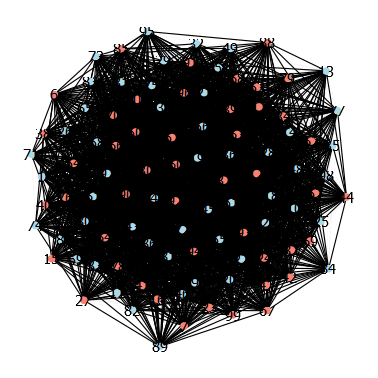

In [17]:
# Ejemplo más grande.
# -----------------------------
# ⚙️ Parámetros del grafo
# -----------------------------
n1 = 100                     # número de nodos
p1 = 0.8                     # probabilidad de arista
max_weight = 10.0           # pesos aleatorios hasta este valor
Random.seed!(123)

# -----------------------------
# 📈 Generar grafo aleatorio
# -----------------------------
g = erdos_renyi(n1, p1)
edges = [(u,v) for u in 1:n1 for v in u+1:n1 if has_edge(g,u,v)]
weights = Dict((u,v)=>rand()*max_weight for (u,v) in edges)

# -----------------------------
# 🧮 Resolver la relajación SDP
# -----------------------------
model = Model(SCS.Optimizer)
set_silent(model)

@variable(model, X[1:n1, 1:n1], PSD)
@constraint(model, [i=1:n1], X[i,i] == 1)
@objective(model, Max, sum(weights[(i,j)] * (1 - X[i,j]) / 2 for (i,j) in edges))

optimize!(model)
X_opt = value.(X)

# -----------------------------
# 🔄 Redondeo aleatorio
# -----------------------------
eigvals, eigvecs = eigen(X_opt)
eigvals_clipped = clamp.(eigvals, 0, Inf)
V = eigvecs * diagm(sqrt.(eigvals_clipped))

r = randn(n1)
cut = [dot(V[i,:], r) >= 0 ? 1 : -1 for i in 1:n1]
cut_value = sum(weights[(i,j)] for (i,j) in edges if cut[i] != cut[j])

println("Asignación de nodos (1 o -1): ", cut)
println("Valor del corte: ", round(cut_value, digits=2))

# -----------------------------
# 🎨 Visualización
# -----------------------------
node_colors = [cut[i] == 1 ? colorant"lightblue" : colorant"salmon" for i in 1:n1]
edge_colors = [cut[u] != cut[v] ? colorant"black" : RGBA(0,0,0,0.1) for (u,v) in edges]
edge_widths = [cut[u] != cut[v] ? 2.5 : 0.5 for (u,v) in edges]

# Graficar
gplot(g;
    nodelabel=1:n1,
    nodefillc=node_colors,
    edgestrokec=edge_colors,
    edgelinewidth=edge_widths,
    layout=spring_layout
)
